In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# For reproducibility
np.random.seed(42)

# Generate sample data for 3 clusters
cluster_1 = {
    'Age': np.random.randint(18, 25, 50),
    'Salary': np.random.randint(15000, 30000, 50)
}

cluster_2 = {
    'Age': np.random.randint(30, 40, 50),
    'Salary': np.random.randint(40000, 60000, 50)
}

cluster_3 = {
    'Age': np.random.randint(45, 60, 50),
    'Salary': np.random.randint(65000, 90000, 50)
}

# Combine into a single DataFrame
df1 = pd.DataFrame(cluster_1)
df2 = pd.DataFrame(cluster_2)
df3 = pd.DataFrame(cluster_3)
df = pd.concat([df1, df2, df3]).reset_index(drop=True)

df.to_csv("D:\\EduNet\\NSTI_Indore25_26\\ML\\Datasets\\SalaryAgeCluster_Synthetic.csv")

# # Scale the data
# scaler = StandardScaler()
# df_scaled = scaler.fit_transform(df)

# # Apply KMeans
# kmeans = KMeans(n_clusters=3, random_state=42)
# df['Cluster'] = kmeans.fit_predict(df_scaled)

# # Plot each cluster with label
# plt.figure(figsize=(8, 6))
# for cluster_id in sorted(df['Cluster'].unique()):
#     cluster_data = df[df['Cluster'] == cluster_id]
#     plt.scatter(cluster_data['Age'], cluster_data['Salary'], label=f'Cluster {cluster_id}', s=50)

# plt.xlabel('Age')
# plt.ylabel('Salary')
# plt.title('K-Means Clustering of Age vs Salary')
# plt.legend(title='Cluster Group')
# plt.grid(True)
# plt.show()

In [3]:
df

,Age,Salary
0,24,18556
1,21,18890
2,22,23838
3,24,29356
4,20,26080
...,...,...
145,56,83639
146,55,66154
147,50,69499
148,57,71295


In [4]:
import matplotlib.pyplot as plt

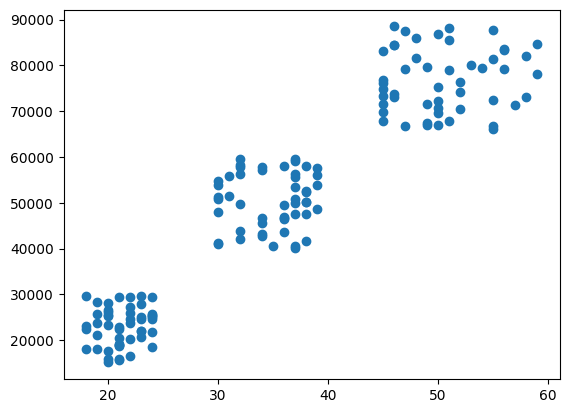

In [6]:
plt.scatter(df['Age'],df['Salary'])

In [8]:
from sklearn.cluster import KMeans

In [10]:
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i)
    model.fit(df)
    wcss.append(model.inertia_)
wcss

[76883978285.53333,
 19175604584.741817,
 4927294329.2,
 3146167505.3761997,
 1850185341.1195333,
 1554441651.3750887,
 981590093.2945664,
 667100002.5589498,
 547852562.7819444,
 484013817.0341004]

In [12]:
clusters = [1,2,3,4,5,6,7,8,9,10]

([<matplotlib.axis.YTick at 0x29d736a6000>,
 [Text(0, 76883978285.53333, '7.688'),
  Text(0, 19175604584.741817, '1.918'),
  Text(0, 4927294329.2, '0.493'),
  Text(0, 3146167505.3761997, '0.315'),
  Text(0, 1850185341.1195333, '0.185'),
  Text(0, 1554441651.3750887, '0.155'),
  Text(0, 981590093.2945664, '0.098'),
  Text(0, 667100002.5589498, '0.067'),
  Text(0, 547852562.7819444, '0.055'),
  Text(0, 484013817.0341004, '0.048')])

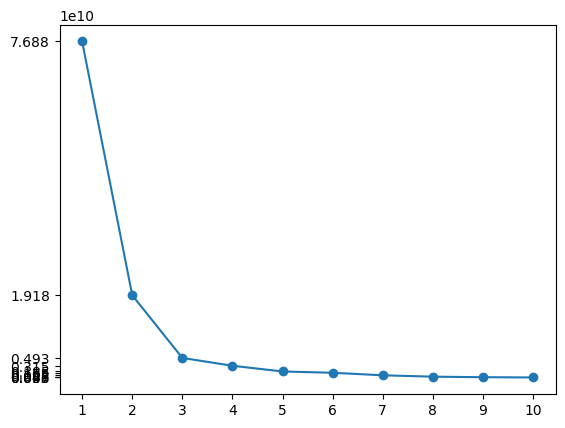

In [26]:
plt.plot(clusters,wcss, marker = 'o')
plt.xticks(clusters)
plt.yticks(wcss)

In [18]:
# I am using 3
model = KMeans(n_clusters=3)
model.fit(df)

KMeans(n_clusters=3)

In [30]:
df['cluster'] = model.predict(df)
df

,Age,Salary,cluster
0,24,18556,1
1,21,18890,1
2,22,23838,1
3,24,29356,1
4,20,26080,1
...,...,...,...
145,56,83639,0
146,55,66154,0
147,50,69499,0
148,57,71295,0


In [31]:
df['cluster'].unique()

array([1, 2, 0])

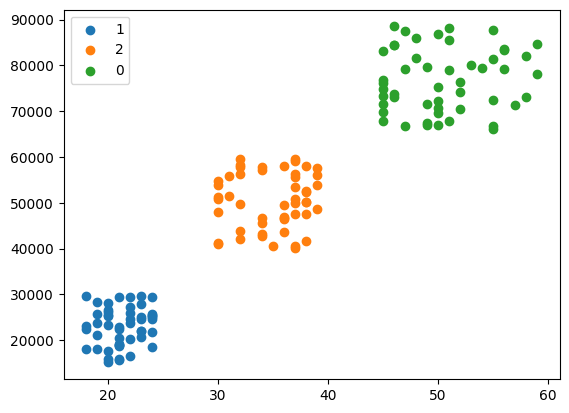

In [39]:
for i in df['cluster'].unique():
    newDF = df[df['cluster'] == i]
    plt.scatter(newDF['Age'],newDF['Salary'],label = i)
plt.legend()
plt.show()

In [40]:
def nameCluster(c):
    # 1: Fresher
    # 2: Intermediate
    # 0: Experienced
    if c == 1:
        return "Fresher"
    elif c == 2:
        return "Intermediate"
    else:
        return "Experienced"

In [41]:
df['Class'] = df['cluster'].apply(lambda x: nameCluster(x))

In [42]:
df

,Age,Salary,cluster,Class
0,24,18556,1,Fresher
1,21,18890,1,Fresher
2,22,23838,1,Fresher
3,24,29356,1,Fresher
4,20,26080,1,Fresher
...,...,...,...,...
145,56,83639,0,Experienced
146,55,66154,0,Experienced
147,50,69499,0,Experienced
148,57,71295,0,Experienced


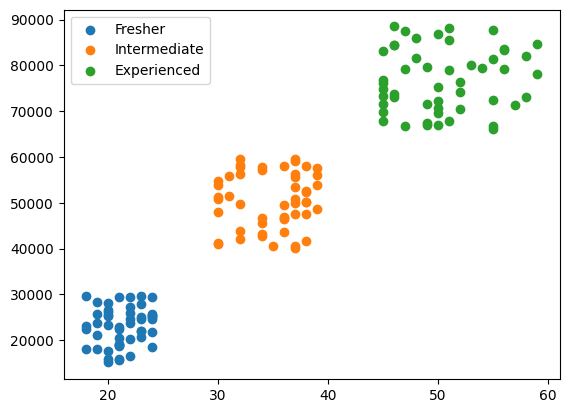

In [46]:
for i in df['Class'].unique():
    newDF = df[df['Class'] == i]
    plt.scatter(newDF['Age'],newDF['Salary'],label = i)
plt.legend()
plt.show()